In [8]:
import torch
import matplotlib.pyplot as plt

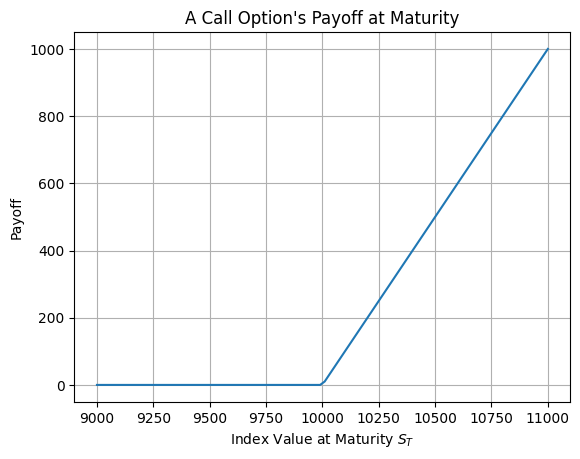

In [9]:
# A Call Option with Strike Price 10000
K = 10000

S = torch.linspace(9000, 11000, 100)
payoff = torch.max(S - K, torch.tensor([0]))

plt.plot(S, payoff)
plt.title("A Call Option's Payoff at Maturity")
plt.xlabel('Index Value at Maturity $S_T$')
plt.ylabel('Payoff')
plt.grid(True)
plt.show()


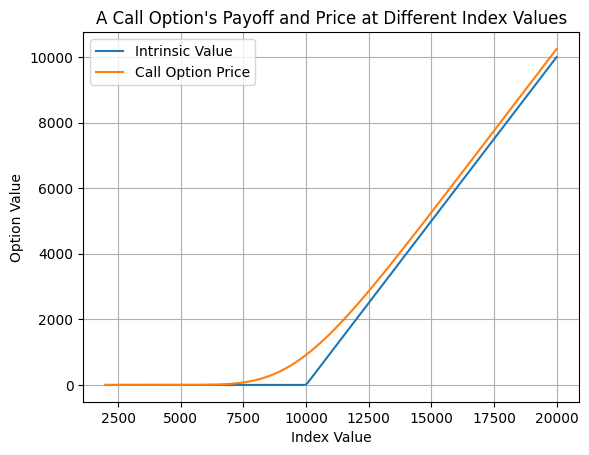

The difference between Call Option Price and Intrinsic Value is Time Value.


In [10]:
# Other Parameters of the Call Option
T = torch.Tensor([1])
r = torch.Tensor([0.025])
vol = torch.Tensor([0.2])

def BSM_call(S0, K, T, r, vol):
    d1 = (torch.log(S0/K) + (r+0.5*vol**2)*T) / vol*torch.sqrt(T)
    d2 = d1 - vol*torch.sqrt(T)

    C = S0*torch.distributions.Normal(0, 1).cdf(d1) - K*torch.exp(-r*T)*torch.distributions.Normal(0, 1).cdf(d2)
    return C

S = torch.linspace(2000, 20000, 200)
payoff = torch.max(S - K, torch.tensor([0]))
call_price = [BSM_call(S0, K, T, r, vol) for S0 in S]

plt.plot(S, payoff, label='Intrinsic Value')
plt.plot(S, call_price, label='Call Option Price')
plt.title("A Call Option's Payoff and Price at Different Index Values")
plt.xlabel("Index Value")
plt.ylabel("Option Value")
plt.legend()
plt.grid(True)
plt.show()

print('The difference between Call Option Price and Intrinsic Value is Time Value.')